In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore") 
import numpy as np
import matplotlib.pyplot as plt 


In [1]:
dict = {
    "AGN": 0,
    "QSO": 1,
    "EA": 2,
    "YSO": 3,
    "SNIa": 4,
    "CV/Nova": 5,
    "RRLc": 6,
    "RSCVn": 7,
    "Blazar": 8,
    "SNII": 9,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}

In [3]:
from ReportPretraining import QuickLoader

ql = QuickLoader(batch_size = 1,experiment_type="MD").validation

MD


/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator QuantileTransformer from version 1.5.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator QuantileTransformer from version 1.5.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/mo

notusingsampler
MD
MD


/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator QuantileTransformer from version 1.5.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(


In [ ]:
import torch
class infout:
    def __init__(self, zerout_n = 3):
        self.zerout_n = zerout_n
    def __call__(self, sample):
        #print(sample['tabular_feat'] )
        #sample['tabular_feat'] = sample['tabular_feat'][0,:,:]
        idxs = torch.randint(0,sample['tabular_feat'].size(0),size  = (self.zerout_n,))
        sample['tabular_feat'][idxs] = -1e-12
        print(sample['tabular_feat'])

In [47]:
test = infout()



In [ ]:
for i in ql:
    print(i['tabular_feat'].shape)
    t = i['tabular_feat']
    print(test(i))
    break

/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/src/data/handlers/CustomDataset.py:150: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data_dict.update({"metadata_feat":torch.tensor(self.metadata_feat[_idx],dtype =  torch.float),})
/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/src/data/handlers/CustomDataset.py:150: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data_dict.update({"metadata_feat":torch.tensor(self.metadata_feat[_idx],dtype =  torch.float),})
/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/src/data/handlers/CustomDataset.py:150: UserWarning: To copy construct from a tensor, it is recommended t

torch.Size([1, 6, 1])
tensor([[[0.3879],
         [0.5414],
         [0.6066],
         [0.4916],
         [0.2808],
         [0.2727]]])
tensor([[-1.0000e-12],
        [ 5.4139e-01],
        [-1.0000e-12],
        [ 4.9164e-01],
        [-1.0000e-12],
        [ 2.7271e-01]])
None


: 

In [ ]:
import seaborn as sns
class ExploreSobel:
    def __init__(self):
        self.magnitude_list,self.sobel_h_list, self.sobel_v_list,self.target = self.generate_sobel_mag_hor_ver()
        df_target = df_target = pd.DataFrame({'target': self.target.astype(int)})
        self.class_indexes = pd.DataFrame({'class':range(0,22),'indexes': [df_target[df_target['target'] == i].index.to_list()  for i in range(0,22)]})

    def generate_sobel_mag_hor_ver(self):
        target = None
        i = 0
        from tqdm import tqdm
        from scipy import ndimage
        import numpy as np
        sobel_h_list = np.empty((len(ql),200,2))# []
        sobel_v_list =np.empty((len(ql),200,2))# []
        magnitude_list = np.empty((len(ql),200,2))# [][]
        
        for b1 in tqdm(ql):
            #b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}
            t = b1['labels'].cpu().detach().numpy()
            signal = b1['data'].detach().cpu().numpy()
            
            sobel_h = ndimage.sobel(signal, 0) * (signal!=0) 
            if sobel_h.max() >1:
                sobel_h = sobel_h/sobel_h.max()
            sobel_h_list[i,:,:] =  sobel_h.squeeze(0)
            
            sobel_v = ndimage.sobel(signal, 1) * (signal!=0) 
            if sobel_v.max() >1:
                sobel_v = sobel_v/sobel_v.max()
            sobel_v_list[i,:,:] =  sobel_v.squeeze(0)
            
            magnitude = np.sqrt(sobel_h**2 + sobel_v**2)  
            magnitude = (magnitude* (signal!=0))
            if magnitude.max() >1:
                magnitude = magnitude/magnitude.max()
            
            magnitude_list[i,:,:] =  magnitude.squeeze(0)
            target = (
                np.concatenate([target, t])
                if target is not None
                else t
            )
            i +=1
        return magnitude_list,sobel_h_list, sobel_v_list, target
        
    def plot_mag(self, xlim = (0,1),ylim = (0,60)):      
        fig,ax = plt.subplots(11,2,figsize = (40,30))    
        ax= ax.flatten()
        for i in range(22):
            if len(self.class_indexes['indexes'].iloc[i]) == 0:
                continue
            mag = self.magnitude_list[self.class_indexes['indexes'].iloc[i]]
            mag = mag.mean(axis = 0) 
            sns.histplot(mag,ax = ax[i], bins = 100) 
            ax[i].set_title(f'Sobel Magnitude Distribution for {list(dict.keys())[i]}', fontsize=12)
            ax[i].set_ylim(ylim)
            ax[i].set_xlim(xlim)
        plt.tight_layout()
        plt.show()  

    def plot_hor(self, xlim = (0,1),ylim = (0,60)):
        fig,ax = plt.subplots(11,2,figsize = (40,30))    
        ax= ax.flatten()
        for i in range(22):
            if len(self.class_indexes['indexes'].iloc[i]) == 0:
                continue
            mag = self.sobel_h_list[self.class_indexes['indexes'].iloc[i]]
            mag = mag.mean(axis = 0) 
            
            sns.histplot(mag,ax = ax[i], bins = 1000) 
            ax[i].set_title(f'Horizontal Sobel Distribution for {list(dict.keys())[i]}', fontsize=12)
            ax[i].set_ylim(ylim)
        
            ax[i].set_xlim(xlim)
            
        plt.tight_layout()
        plt.show()

    def plot_vertical(self, xlim = (0,1),ylim = (0,60)):
        fig,ax = plt.subplots(11,2,figsize = (40,30))    
        ax= ax.flatten()
        for i in range(22):
            if len(self.class_indexes['indexes'].iloc[i]) == 0:
                continue
            mag = self.sobel_v_list[self.class_indexes['indexes'].iloc[i]]
            mag = mag.mean(axis = 0)
            sns.histplot(mag,ax = ax[i], bins = 1000)
            ax[i].set_title(f'Vertical Sobel Distribution for {list(dict.keys())[i]}', fontsize=12)
            ax[i].set_ylim(ylim)
        
            ax[i].set_xlim(xlim)
            
        plt.tight_layout()
        plt.show()

In [ ]:
sobel = ExploreSobel()

sobel.magnitude_list.shape

100%|██████████| 40698/40698 [02:05<00:00, 324.93it/s]


(40698, 200, 2)

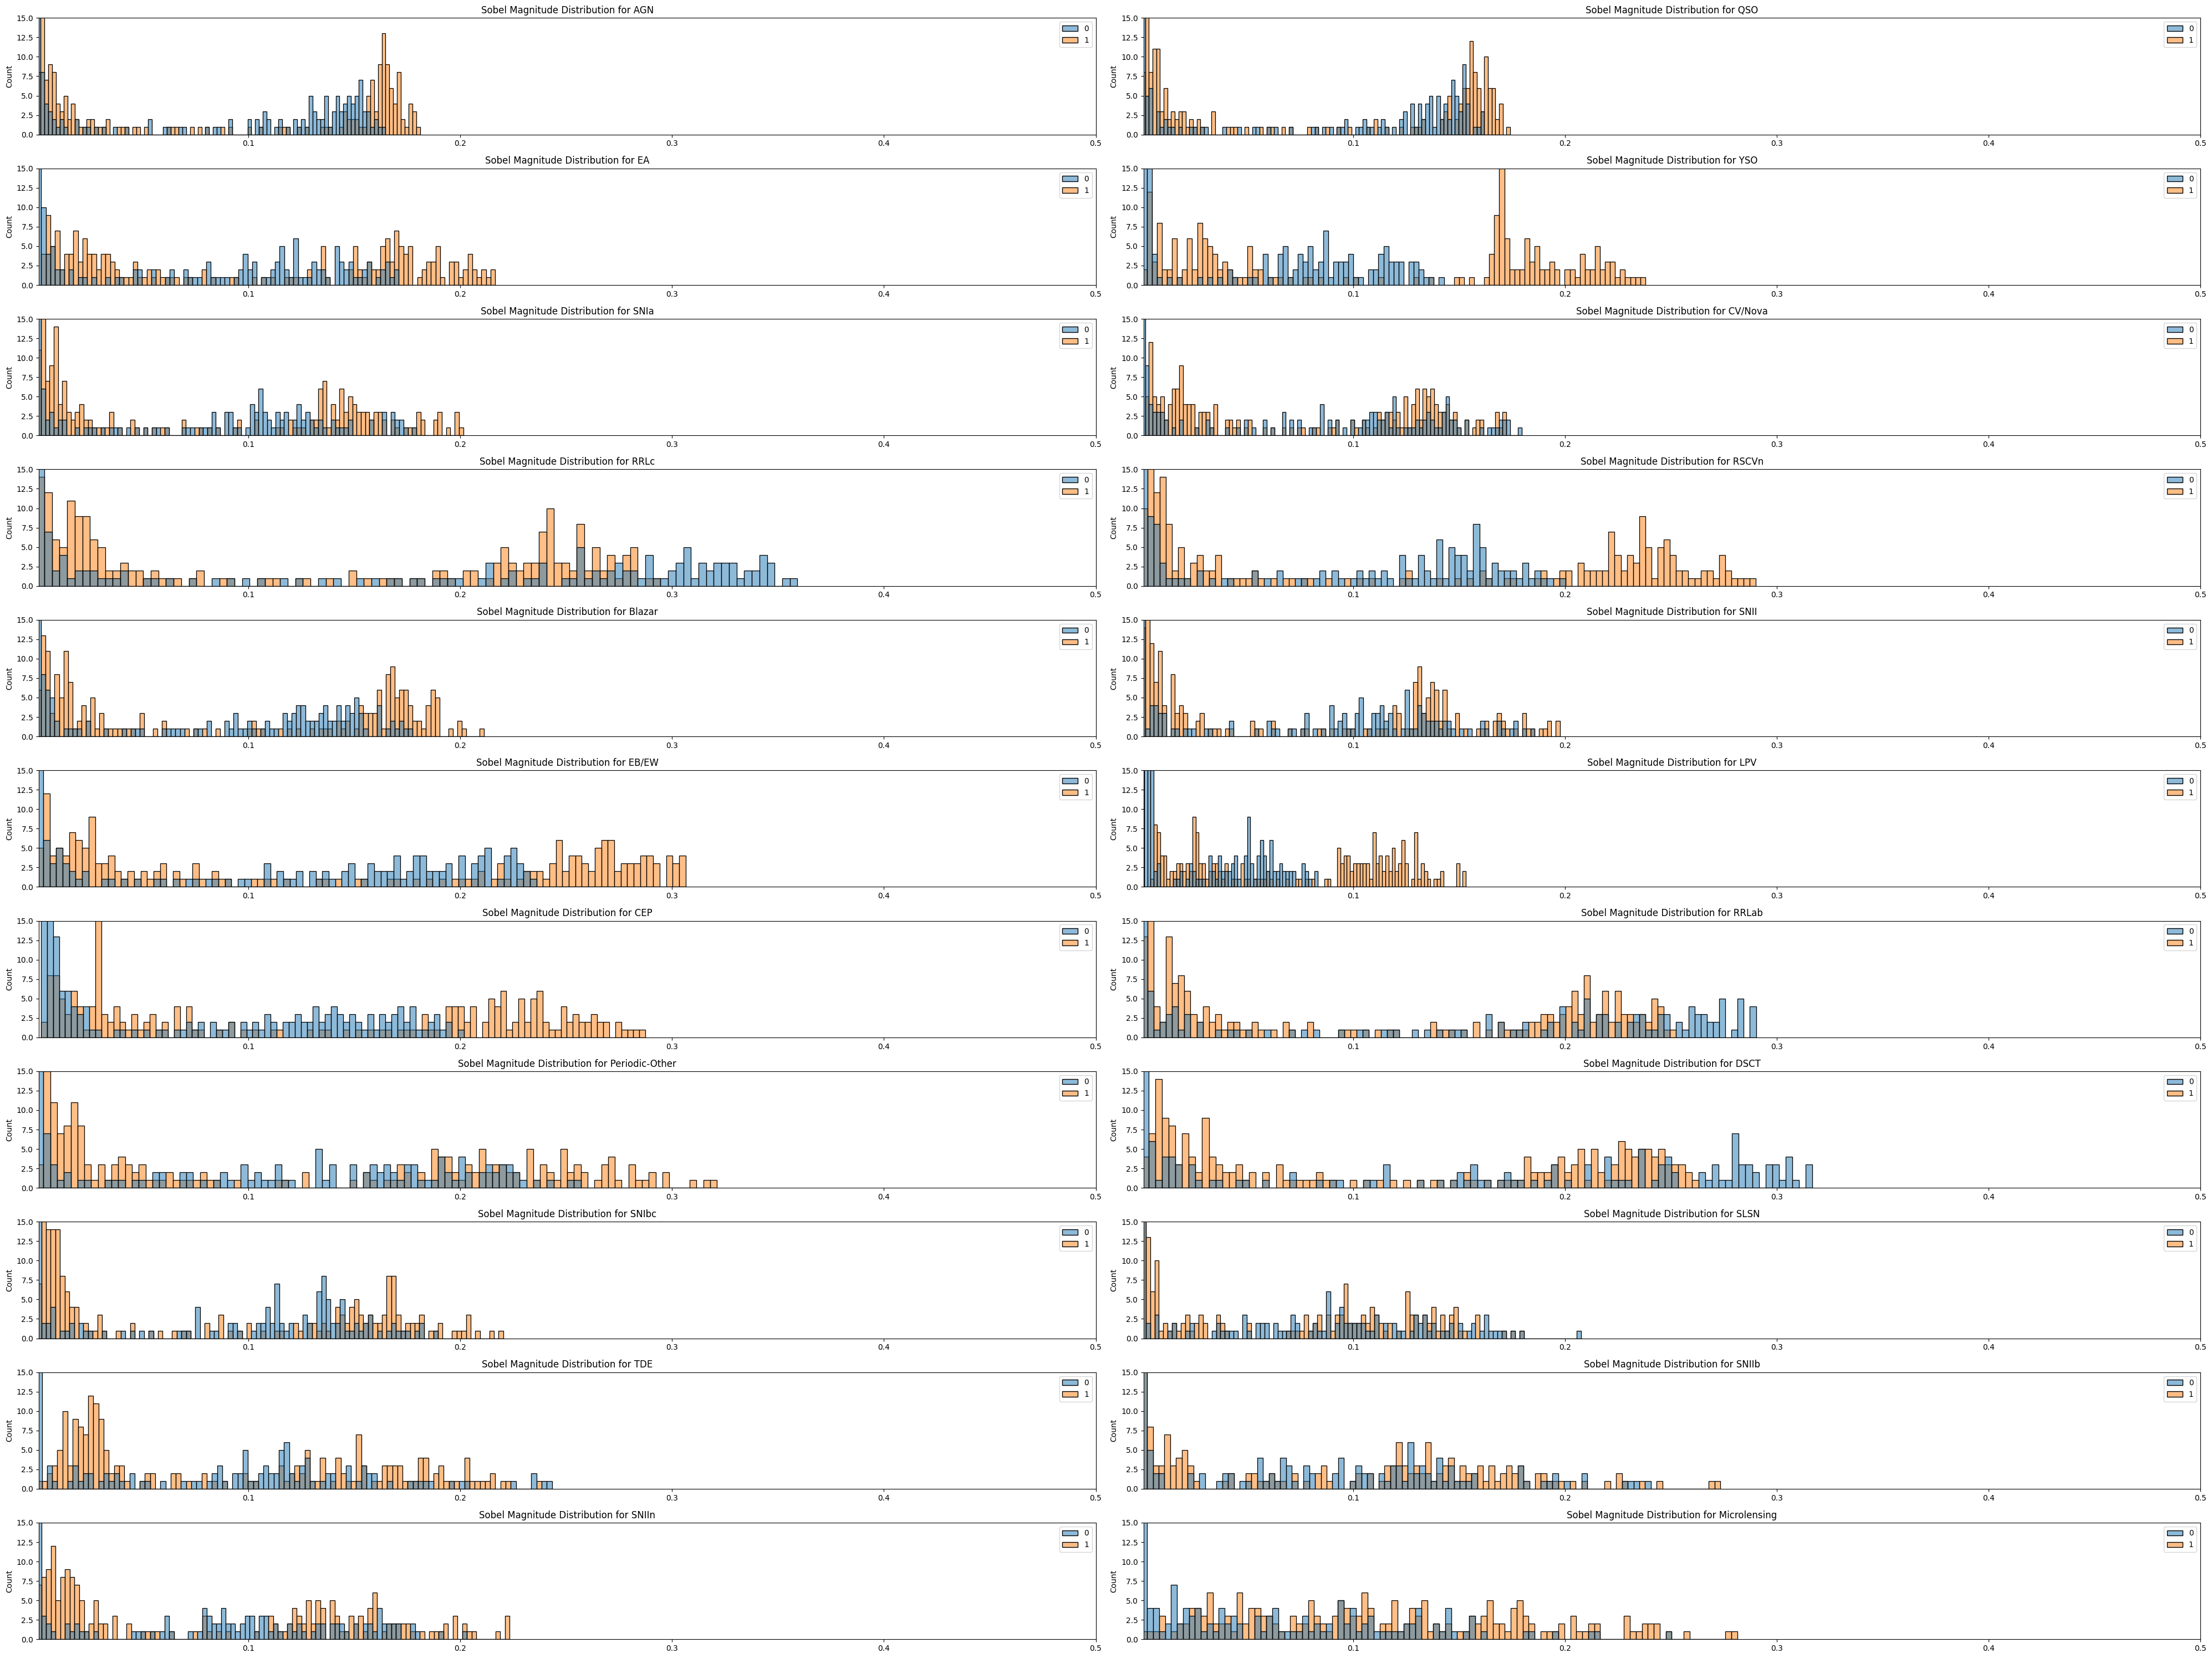

In [ ]:

sobel.plot_mag(xlim = (0.001,0.5), ylim = (0,15))

In [ ]:
#sobel.plot_hor(xlim = (0.0,0.1), ylim = (0,15))

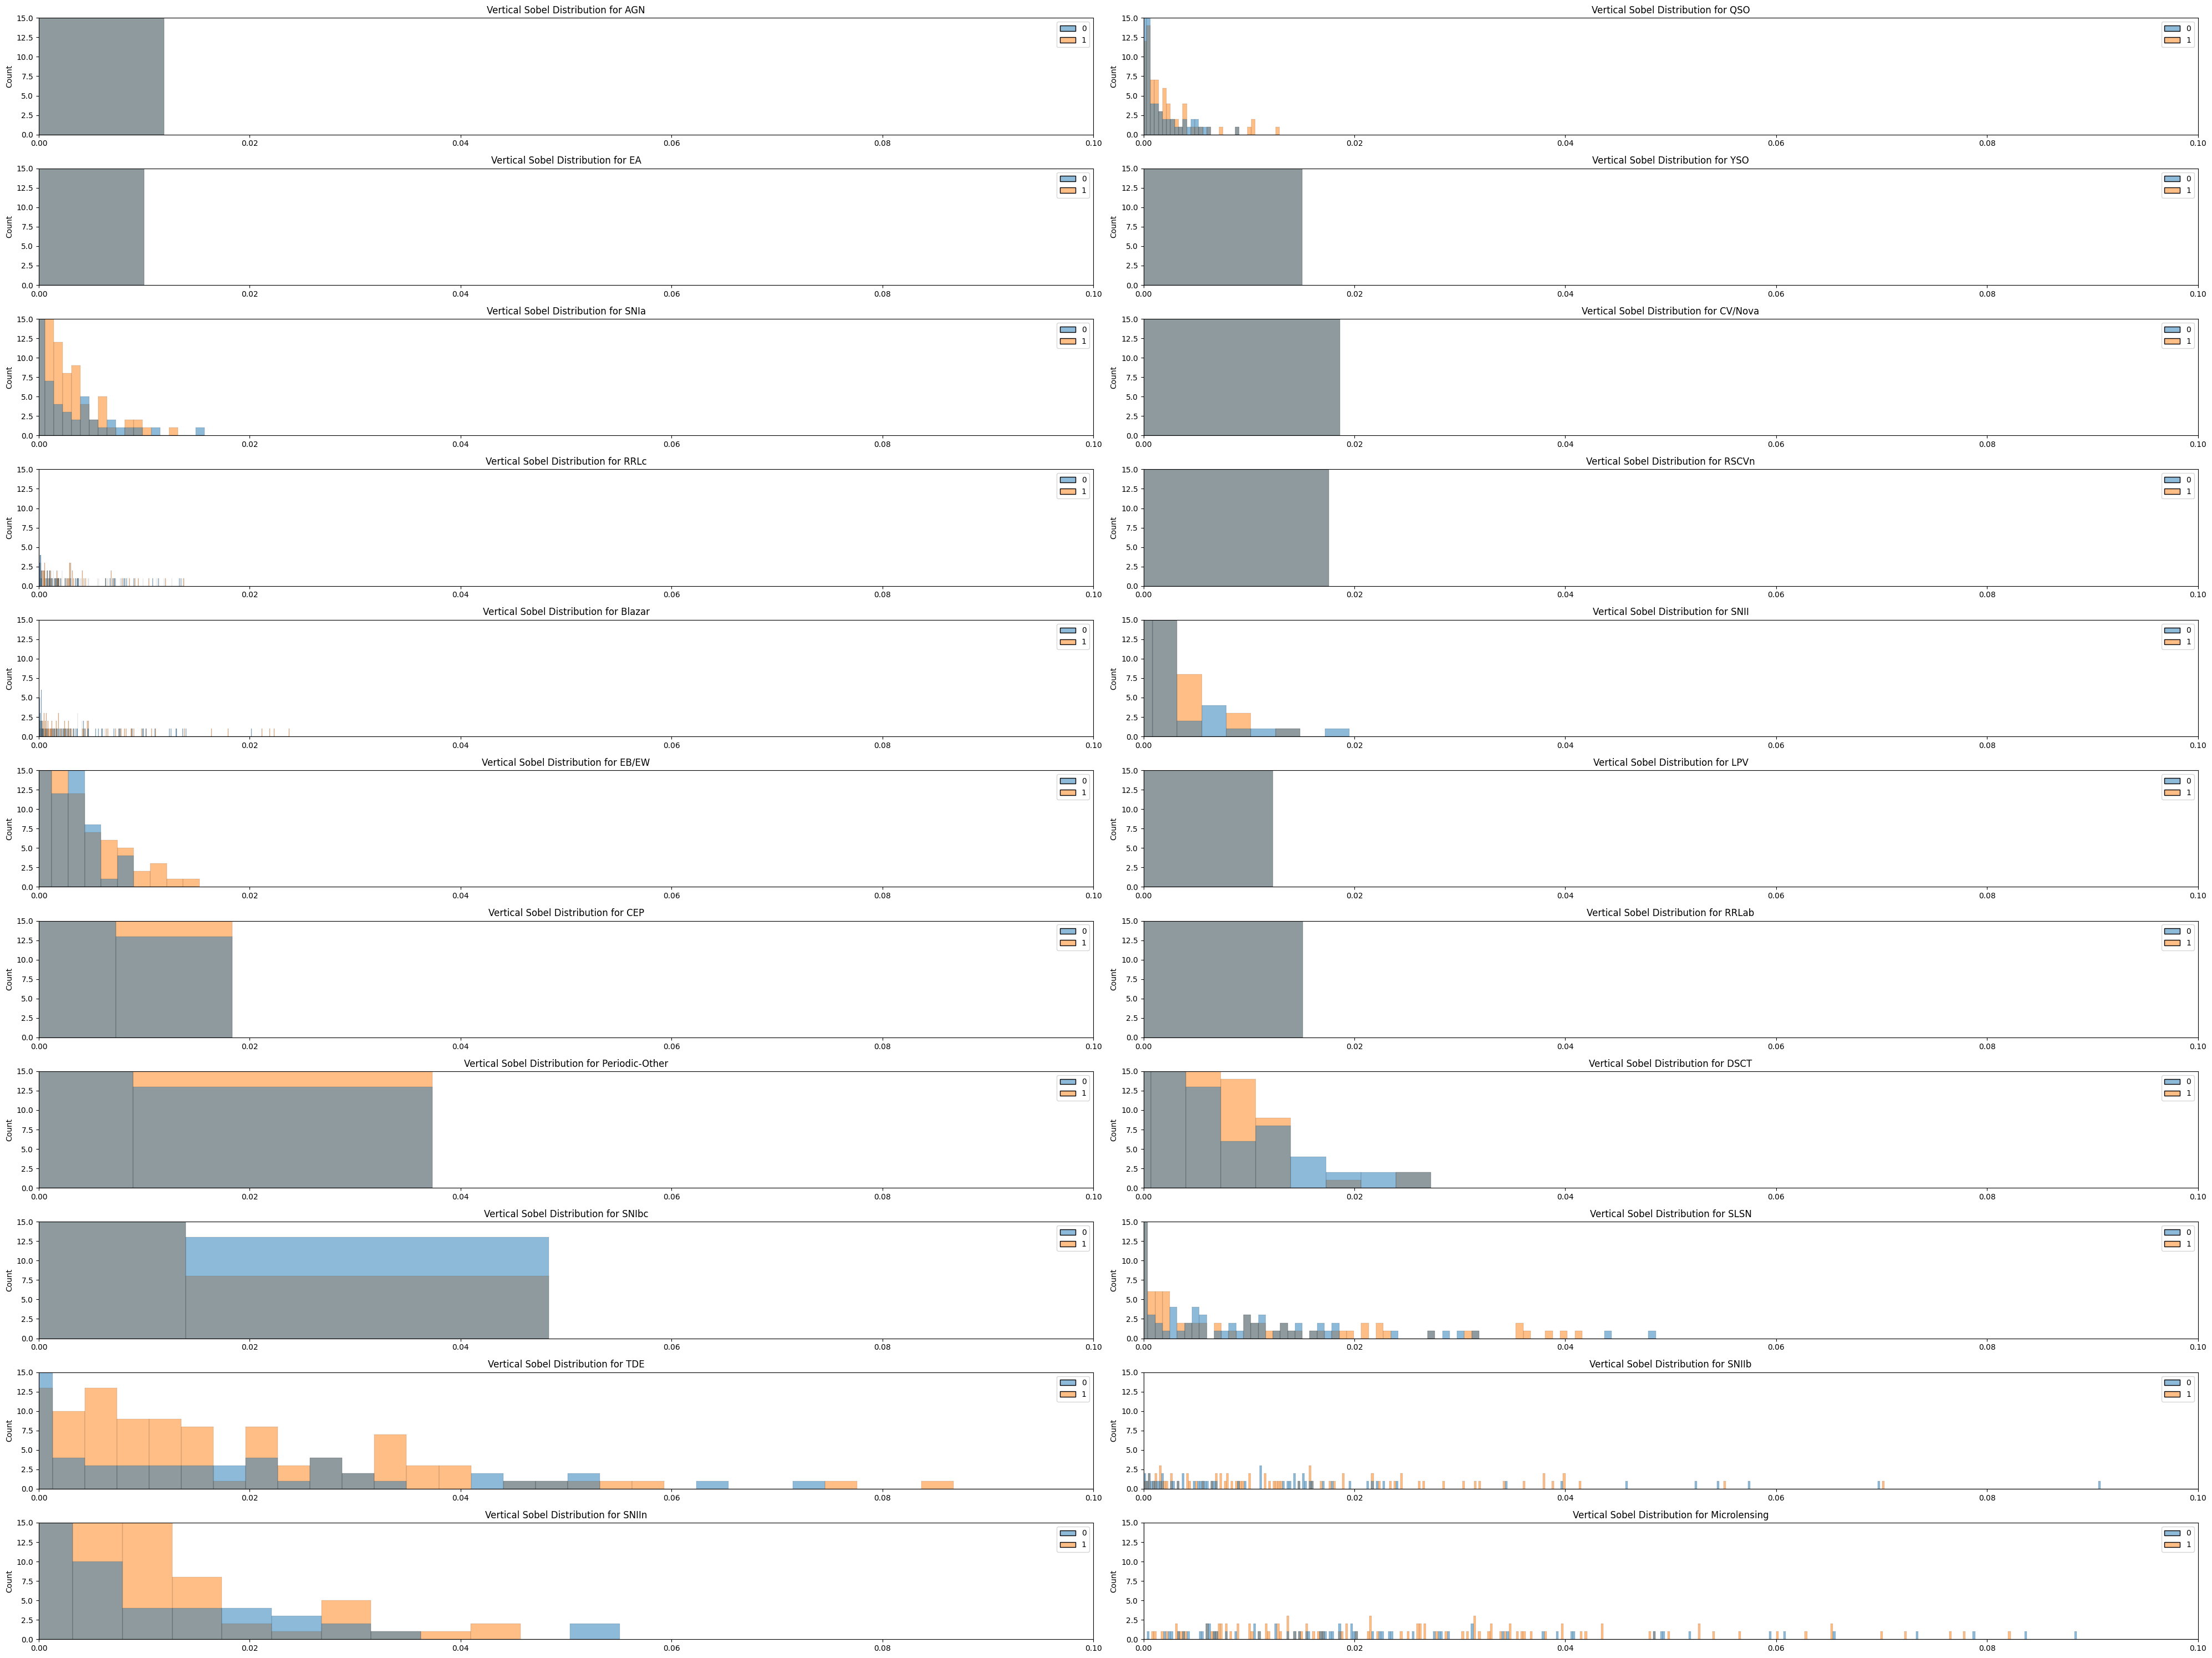

In [ ]:
sobel.plot_vertical(xlim = (0.0,0.1), ylim = (0,15))

In [ ]:
asdfad

NameError: name 'asdfad' is not defined

In [ ]:

from scipy import ndimage, datasets 
n = 0 # np.random.randint(0,32)
signal = b1['data'][n,:,:].detach().cpu().numpy()
signal_mask = b1['mask'][n,:,:].detach().cpu().numpy()

sobel_h = ndimage.sobel(signal, 0) * (signal!=0) # horizontal gradient
sobel_v = ndimage.sobel(signal, 1)  * (signal!=0)  # vertical gradient
print(sobel_h.shape) 



NameError: name 'b1' is not defined

In [ ]:
from torchvision.transforms import Compose
import seaborn as sns
from src.augmentations import LightCurveTransform as LC
transform = Compose([LC.RandomSobelFilterMask(filter_type = 'horizontal',keep = 'below',threshold_range=(0.1,0.101))])

In [ ]:
target = None
preds_out = None
 
count = 0
import matplotlib.pyplot as plt
from scipy import ndimage, datasets
import torch 
from copy import deepcopy
sobel_h_list = []
sobel_v_list = []
magnitude_list = []

for b1 in tqdm(ql):
    #b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}
    #print(b1['data'].squeeze(0).shape)
    for key,value in b1.items():
        b1[key] = value.squeeze(0)
     
    t = b1['labels']
    item = b1
    copied = deepcopy(item)
    test = transform(copied)
    #fig,ax = plt.subplots(1,2)
    #sns.heatmap(item['mask'],ax = ax[0])
    #sns.heatmap(test['mask'],ax = ax[1])
    #plt.show()
    if count > 10:
        break
    count +=1
    
 

 14%|█▍        | 11/80 [00:00<00:03, 20.12it/s]


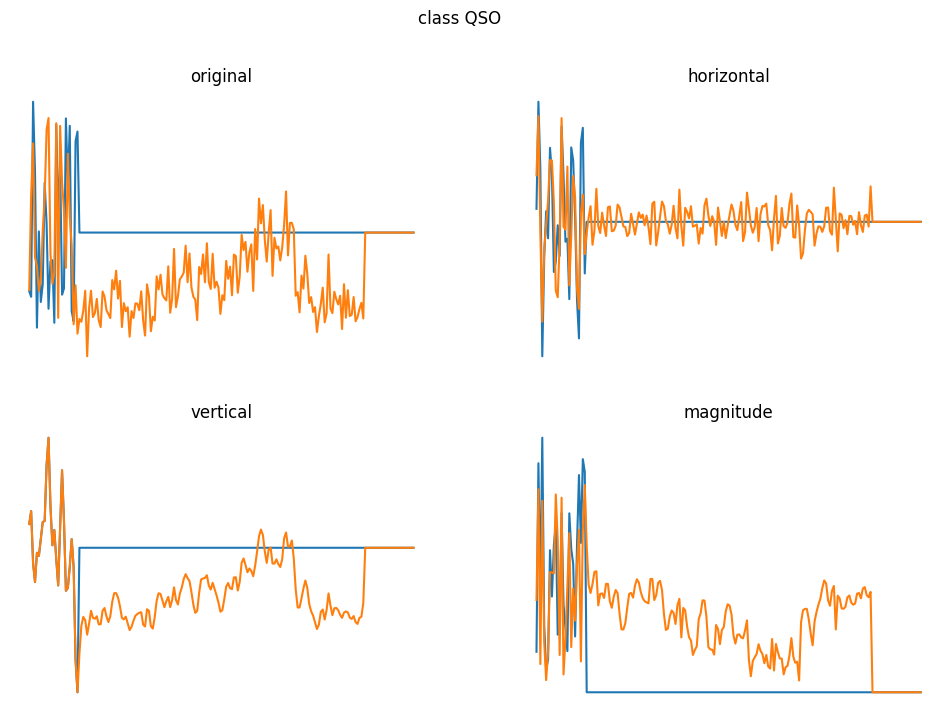

<Axes: >

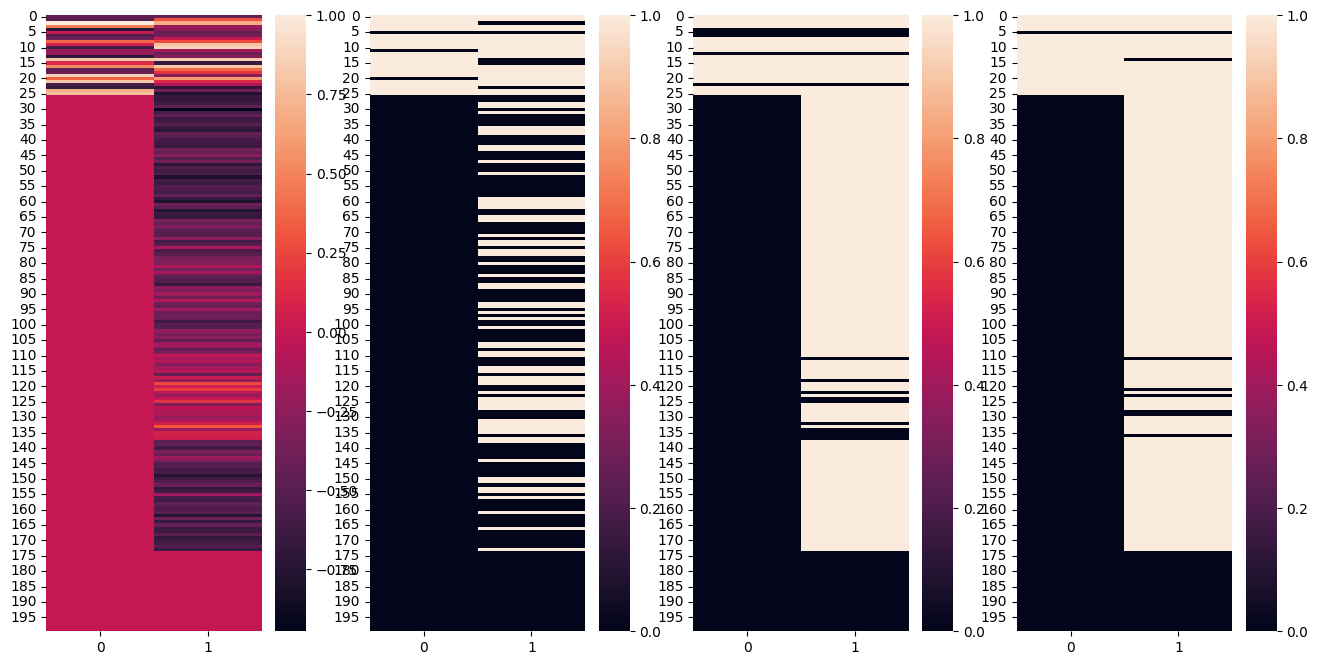

In [ ]:
import seaborn as sns
magnitude = np.sqrt(sobel_h**2 + sobel_v**2)  * (signal!=0) 
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
plt.gray()  # show the filtered result in grayscale
axs[0, 0].plot(signal)
axs[0, 1].plot(sobel_h)
axs[1, 0].plot(sobel_v)
axs[1, 1].plot(magnitude)

titles = ["original", "horizontal", "vertical", "magnitude"]
for i, ax in enumerate(axs.ravel()):
    ax.set_title(titles[i])
    ax.axis("off")
plt.suptitle(f'class {list(dict.keys())[b1['labels'][n].int()]}')
plt.show()

fig,ax = plt.subplots(1,4,figsize = (16,8))
sns.heatmap(signal/signal.max() * (signal !=0),ax = ax[0])
sns.heatmap((abs(sobel_h/sobel_h.max()* (signal !=0))>1e-1)& signal_mask,ax = ax[1])
sns.heatmap((abs(sobel_v/sobel_v.max()* (signal !=0))>1e-1) & signal_mask,ax = ax[2])
sns.heatmap((((magnitude/magnitude.max()* (signal !=0))> 1e-1) & signal_mask),ax = ax[3])


In [ ]:
magnitude_list.shape

torch.Size([0])

,class,indexes
0,0,"[57, 58, 59, 60, 61, 62, 63, 64, 71, 72, 73, 7..."
1,1,"[144, 145, 146, 147, 148, 149, 150, 151, 152, ..."
2,2,"[13, 14, 15, 16, 17, 18, 19, 128, 129, 130, 13..."
3,3,"[106, 107, 108, 109, 110, 111, 112, 113, 308, ..."
4,4,"[65, 66, 67, 68, 69, 70, 452, 453, 454, 455, 4..."
5,5,"[239, 240, 241, 242, 243, 244, 245, 246, 247, ..."
6,6,"[8, 9, 10, 11, 12, 78, 79, 80, 81, 82, 83, 84,..."
7,7,"[51, 833, 834, 835, 1271, 1272, 1273, 1274, 13..."
8,8,"[47, 48, 49, 50, 52, 53, 54, 55, 56, 91, 92, 9..."
9,9,"[353, 354, 355, 448, 462, 783, 784, 785, 786, ..."


In [ ]:
asdfasf

NameError: name 'asdfasf' is not defined

asdfadsf

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d, gaussian_filter
import seaborn as sns
rng = np.random.default_rng()
signal = b1['data'][12,:,0]
#signal = signal[signal.nonzero()]
signal = signal.detach().cpu().numpy()
y3 = gaussian_filter1d(signal, 0.02)
y6 = gaussian_filter1d(signal, 0.05)

y3 = (signal != 0)*y3
plt.plot(signal, 'k', label='original data',alpha = 0.5)
plt.plot(y3, '--', label='filtered, sigma=3', color = 'red')
plt.plot(y6, ':', label='filtered, sigma=1', color = 'blue')
plt.legend()

plt.show()

fig,ax = plt.subplots(1,2,figsize = (12,4))
rng = np.random.default_rng()
signal = b1['data'][12,:,:]
#signal = signal[signal.nonzero()]
signal = signal.detach().cpu().numpy() 
y3 = gaussian_filter(signal, 0.5) * (signal !=0)


sns.heatmap(signal/signal.max(),ax = ax[0],cmap = 'viridis')
sns.heatmap(y3/y3.max(),ax = ax[1],cmap = 'viridis')

plt.legend()

plt.show()





In [ ]:
from scipy import ndimage, datasets 

signal = b1['data'][1,:,:].detach().cpu().numpy()

sobel_h = ndimage.sobel(signal, 0)  # horizontal gradient
sobel_v = ndimage.sobel(signal, 1)  # vertical gradient
print(sobel_h.shape) 

magnitude = np.sqrt(sobel_h**2 + sobel_v**2)
#magnitude *= 255.0 / np.max(magnitude)  # normalization
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
plt.gray()  # show the filtered result in grayscale
axs[0, 0].plot(signal)
axs[0, 1].plot(sobel_h)
axs[1, 0].plot(sobel_v)
axs[1, 1].plot(magnitude)
plt.legend(['signal','sobel_h','sobel_v','mag'])

titles = ["original", "horizontal", "vertical", "magnitude"]
for i, ax in enumerate(axs.ravel()):
    ax.set_title(titles[i])
    ax.axis("off")
plt.show()

fig,ax = plt.subplots(1,4,figsize = (16,8))
sns.heatmap(signal/signal.max() * (signal !=0),ax = ax[0])
sns.heatmap(sobel_h/sobel_h.max()* (signal !=0),ax = ax[1])
sns.heatmap(sobel_v/sobel_v.max()* (signal !=0),ax = ax[2])
sns.heatmap(magnitude/magnitude.max()* (signal !=0),ax = ax[3])

In [ ]:
def big_group_plot_umap(ax, umap_result, numeric_labels, num_classes, title):
    colors = ['cyan','yellow','magenta']
    transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
    }
    stochastic =  {
        "AGN": 0,
        "QSO": 1,
        "YSO": 3,
        "CV/Nova": 5,
        "Blazar": 8,
    }
    periodic =  {
        "EA": 2,
        "RRLc": 6,
        "RSCVn": 7,
        "EB/EW": 10,
        "LPV": 11,
        "CEP": 12,
        "RRLab": 13,
        "Periodic-Other": 14,
        "DSCT": 15,
    }
    
    for i in range(num_classes):
        class_indices = numeric_labels == i
        color = colors[0] if i in transient.values() else (colors[1] if i in stochastic.values() else colors[2])
        ax.scatter(x=umap_result[class_indices, 0], y=umap_result[class_indices, 1],s=7, color=color,alpha = 0.45) 
        

    ax.set_facecolor('black')
    
    ax.set_title(title)
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    plt.legend(['transient', 'stochastic','periodic'])
    
    

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(25, 25))

big_group_plot_umap(axs, umap_result, target, 21,  'UMAP Visualization - concatenated embeddings ')